In [22]:
from collections import Counter
from pathlib import Path
from rdkit import Chem
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
import os

In [2]:
OUTPUT_PATH = Path("../data/QuantumFP/QFP_output")

# get QFP directory path
output_files: list[Path] = [int(path.split('.')[0].split('_')[-1]) for path in os.listdir(OUTPUT_PATH) if path.endswith(".gz")]

print(sorted(output_files))

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221,

In [3]:
missing = [i for i in range(8845) if i not in output_files]
print(missing)

[895, 1226, 1611, 1650, 2094, 2216, 5262, 5882]


In [4]:
with open("../data/QuantumFP/QFP_input.json", "r") as f:
    data = json.load(f)


used_smiles = [datapoint["smiles"] for datapoint in data["inputs"] if not datapoint["id"] in missing]
print(len(used_smiles))

8837


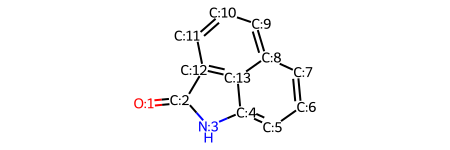

In [5]:
Chem.MolFromSmiles(used_smiles[0])

In [6]:
unwanted_atoms = ['Cd', 'W', 'Te', 'Mn', 'Nb', 'Cr', 'Sb', 'Ge', 'Ca', 'Bi', 'Y', 'Al', 'Sr', 'Fe', 'Ni', 'Ti', 'Zr', 'Be', 'Ce', 'Hg']
len(unwanted_atoms)

20

In [7]:
total_atom_types = []
count = 0
for smiles in used_smiles:
    mol = Chem.MolFromSmiles(smiles)

    mol_atom_types = [atom.GetSymbol() for atom in mol.GetAtoms()]

    if any(atom in unwanted_atoms for atom in mol_atom_types):
        count += 1
    else:
        total_atom_types.extend(mol_atom_types)

In [8]:
print(count)

24


In [9]:
print(Counter(total_atom_types))

Counter({'C': 104713, 'O': 21994, 'N': 10482, 'Cl': 3754, 'S': 1869, 'F': 1204, 'Br': 474, 'P': 332, 'I': 133, 'Si': 93, 'Sn': 18, 'Se': 10, 'B': 9, 'Pb': 6, 'Co': 5, 'Zn': 4, 'Cu': 4, 'As': 4, 'V': 3, 'Mo': 3, 'H': 1})


In [10]:
779 - (21 * 19)

380

In [11]:
21*19

399

In [12]:
from library import QuantumFPFileLoader, QFPFeatureEngineer, ConformerAggregator, QuantumFPDatasetBuilder

loader = QuantumFPFileLoader(OUTPUT_PATH)
output_files = loader.list_output_files()

for df in loader.stream_conformer_dataframe(output_files[3]):
    tdf = df

In [13]:
engineer = QFPFeatureEngineer(300.0)
tdf = engineer.clean_features(tdf)

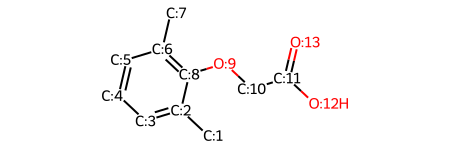

In [14]:
Chem.MolFromSmiles(tdf["original_smiles"][0])

In [15]:
print(tdf.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 57 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   energy                                       7 non-null      Float64
 1   atomization_energy                           7 non-null      Float64
 2   homo_lumo_gap                                7 non-null      Float64
 3   ionization_energy                            7 non-null      Float64
 4   electron_affinity                            7 non-null      Float64
 5   chemical_potential                           7 non-null      Float64
 6   molecular_dipole_norm                        7 non-null      Float64
 7   molecular_quadrupole_principal_invariant_2   7 non-null      Float64
 8   molecular_quadrupole_principal_invariant_3   7 non-null      Float64
 9   molecular_polarizability_mean                7 non-null      Float64
 10  molecu

In [20]:
tdf["ir_centroid_freq_1500"]

0    1050.092594
1    1062.781248
2    1050.015182
3    1020.314176
4    1005.099186
5    1005.193721
6    1021.919425
Name: ir_centroid_freq_1500, dtype: Float64

In [17]:
aggregator = ConformerAggregator()

molecule_series = aggregator.thermal_average(tdf)

In [18]:
molecule_series

smiles                                         [C:1]([c:2]1[c:3]([H:17])[c:4]([H:18])[c:5]([H...
energy                                                                                -39.453112
atomization_energy                                                                      5.850939
homo_lumo_gap                                                                           0.073945
ionization_energy                                                                       0.299042
electron_affinity                                                                       0.004866
chemical_potential                                                                     -0.145684
molecular_dipole_norm                                                                   5.103982
molecular_quadrupole_principal_invariant_2                                          -1306.769545
molecular_quadrupole_principal_invariant_3                                          16565.487506
molecular_polarizability_mean 

In [24]:
builder = QuantumFPDatasetBuilder(OUTPUT_PATH, cap=20)
df = builder.build_dataset()

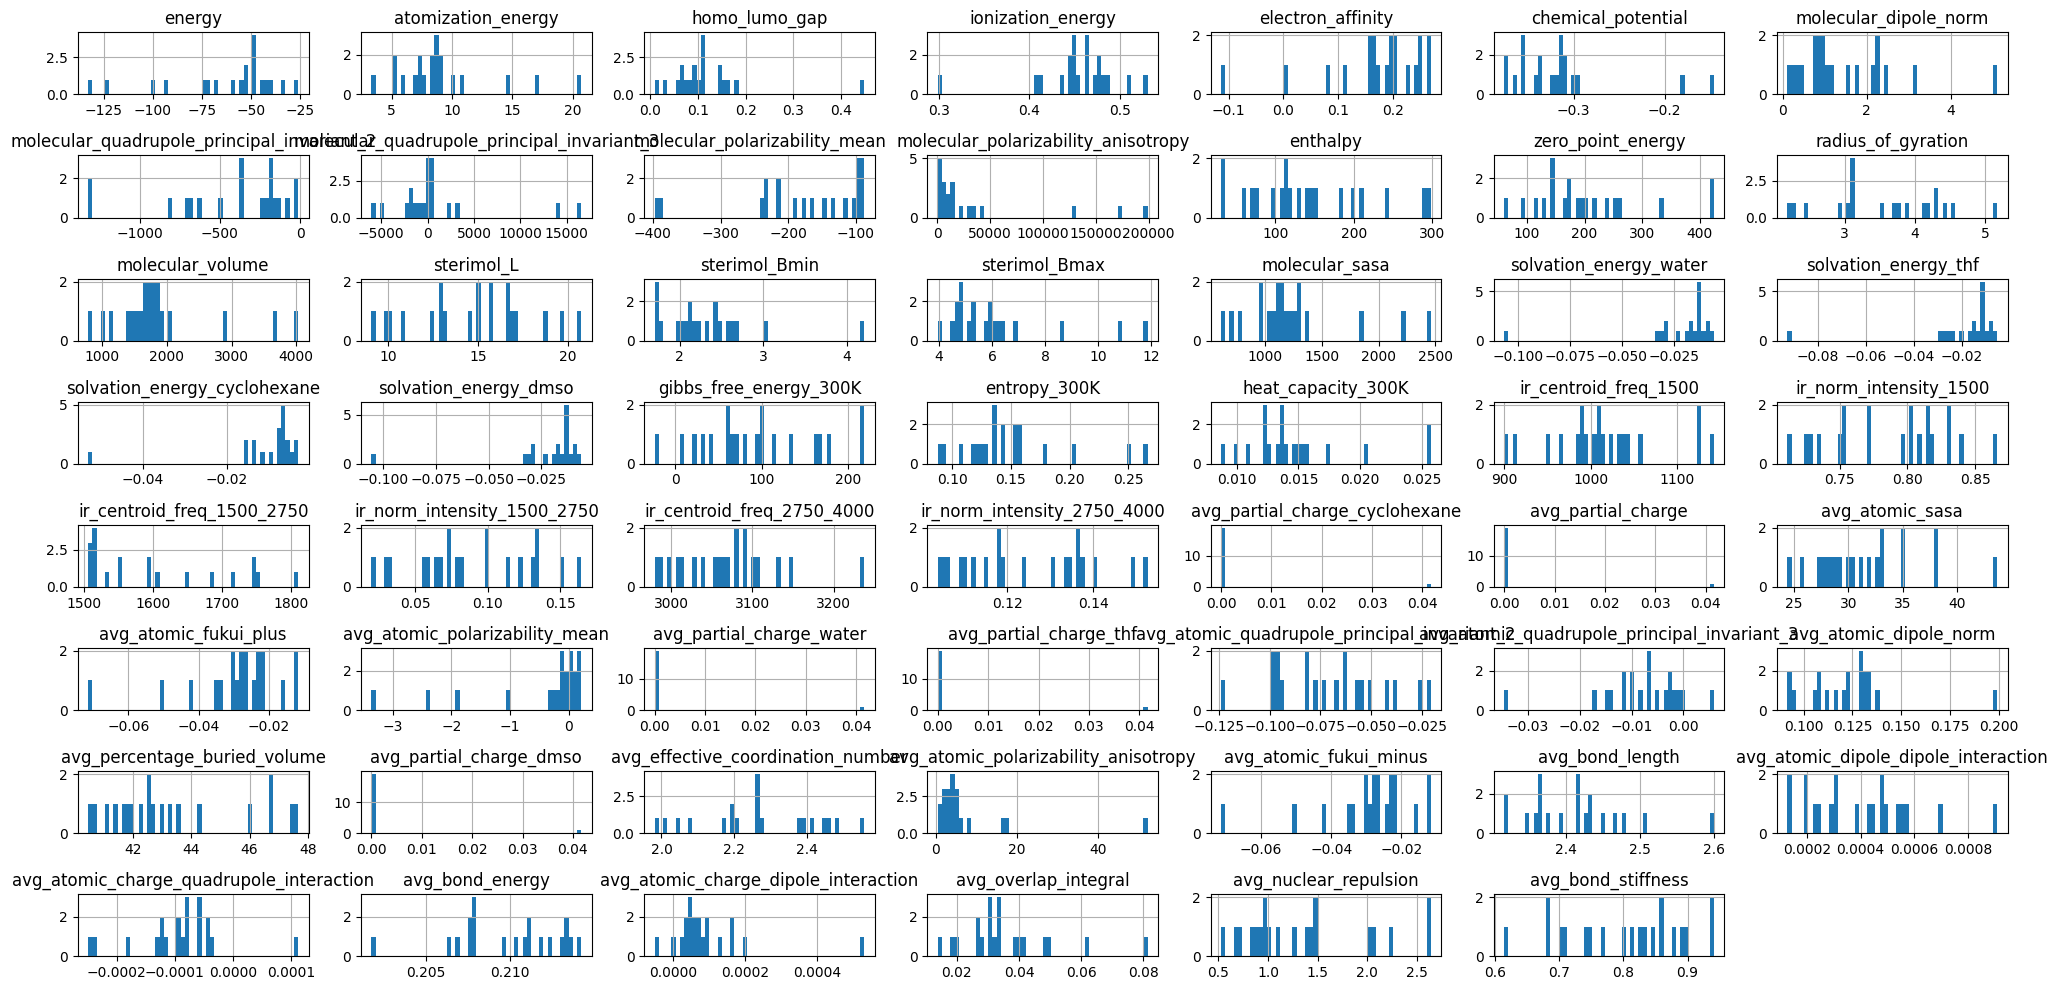

In [27]:
subset_feature_df = df.drop("smiles", axis=1)
subset_feature_df.hist(bins=50, figsize=(20,10))
plt.tight_layout()
plt.grid(False)
plt.show()